In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import tensorflow as tf
import numpy as np

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    bce    = -y_true * tf.math.log(y_pred) - (1.0 - y_true) * tf.math.log(1.0 - y_pred)
    p_t    = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
    focal_w = alpha * tf.pow(1.0 - p_t, gamma)
    return tf.reduce_mean(focal_w * bce)

def focal_dice_loss(y_true, y_pred):
    return 0.5 * focal_loss(y_true, y_pred) + 0.5 * (1.0 - dice_coefficient(y_true, y_pred))

CUSTOM_OBJECTS = {
    'focal_dice_loss':  focal_dice_loss,
    'dice_coefficient': dice_coefficient,
    'focal_loss':       focal_loss
}

print("Loss functions defined ✓")

Loss functions defined ✓


In [ ]:
BASE  = '/content/drive/MyDrive/LungTumour/'
LOCAL = '/content/lung_data/'

# Load TEST data — not val, test is the honest evaluation set
X_test = np.load(BASE + 'X_test.npy')
y_test = np.load(BASE + 'y_test.npy')

# Transpose to (N, 8, 128, 128, 1)
# X_test = np.transpose(X_test, (0, 3, 1, 2, 4))
# y_test = np.transpose(y_test, (0, 3, 1, 2, 4))

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Load NB3 best model
model = tf.keras.models.load_model(
    BASE + 'NB3_best.keras',
    custom_objects=CUSTOM_OBJECTS
)

print("NB3_best.keras loaded ✓")
model.summary()

X_test shape: (395, 8, 128, 128, 1)
y_test shape: (395, 8, 128, 128, 1)
NB3_best.keras loaded ✓


Model: "Attention_UNet_3D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8, 128,    │          0 │ -                 │
│ (InputLayer)        │ 128, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 8, 128,    │        448 │ input_layer[0][0] │
│                     │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 128,    │         64 │ conv3d[0][0]      │
│ (BatchNormalizatio… │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 8, 128,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 8, 128,    │      6,928 │ activation[0][0]  │
│                     │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 128,    │         64 │ conv3d_1[0][0]    │
│ (BatchNormalizatio… │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 8, 128,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout3d   │ (None, 8, 128,    │          0 │ activation_1[0][… │
│ (SpatialDropout3D)  │ 128, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 8, 64, 64, │          0 │ spatial_dropout3… │
│ (MaxPooling3D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 8, 64, 64, │     13,856 │ max_pooling3d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 64, 64, │        128 │ conv3d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 8, 64, 64, │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 8, 64, 64, │     27,680 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 64, 64, │        128 │ conv3d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 8, 64, 64, │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout3d_1 │ (None, 8, 64, 64, │          0 │ activation_3[0][… │
│ (SpatialDropout3D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 8, 32, 32, │          0 │ spatial_dropout3

 Total params: 4,433,790 (16.91 MB)

 Trainable params: 1,477,460 (5.64 MB)

 Non-trainable params: 1,408 (5.50 KB)

 Optimizer params: 2,954,922 (11.27 MB)

In [ ]:
y_pred = model.predict(X_test, batch_size=2, verbose=1)
y_pred_bin = (y_pred > 0.5).astype(np.float32)

print("Predictions shape:", y_pred.shape)
print("Predictions done ✓")

198/198 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step
Predictions shape: (395, 8, 128, 128, 1)
Predictions done ✓


In [ ]:
def compute_metrics(y_true, y_pred_bin):
    results = []
    for i in range(len(y_true)):
        gt   = y_true[i].flatten()
        pred = y_pred_bin[i].flatten()
        TP = np.sum(gt * pred)
        FP = np.sum((1 - gt) * pred)
        FN = np.sum(gt * (1 - pred))
        TN = np.sum((1 - gt) * (1 - pred))
        results.append({
            'dice':        (2*TP + 1e-6) / (2*TP + FP + FN + 1e-6),
            'iou':         (TP  + 1e-6) / (TP  + FP + FN + 1e-6),
            'sensitivity': (TP  + 1e-6) / (TP  + FN + 1e-6),
            'precision':   (TP  + 1e-6) / (TP  + FP + 1e-6),
            'specificity': (TN  + 1e-6) / (TN  + FP + 1e-6)
        })
    return results

results = compute_metrics(y_test, y_pred_bin)

metrics = ['dice', 'iou', 'sensitivity', 'precision', 'specificity']
print("\n===== Test Set Metrics (NB3_best) =====")
for m in metrics:
    vals = [r[m] for r in results]
    print(f"{m:>12s}:  mean={np.mean(vals):.4f}  std={np.std(vals):.4f}  min={np.min(vals):.4f}  max={np.max(vals):.4f}")


===== Test Set Metrics (NB3_best) =====
        dice:  mean=0.7842  std=0.1465  min=0.0000  max=0.9524
         iou:  mean=0.6638  std=0.1586  min=0.0000  max=0.9091
 sensitivity:  mean=0.8136  std=0.1761  min=0.0000  max=1.0000
   precision:  mean=0.7999  std=0.1722  min=0.0000  max=1.0000
 specificity:  mean=0.9993  std=0.0016  min=0.9845  max=1.0000


In [ ]:
# Separate good vs bad predictions
dice_scores = [r['dice'] for r in results]
dice_scores = np.array(dice_scores)

perfect    = np.sum(dice_scores > 0.85)
good       = np.sum((dice_scores > 0.70) & (dice_scores <= 0.85))
mediocre   = np.sum((dice_scores > 0.40) & (dice_scores <= 0.70))
failed     = np.sum((dice_scores > 0.01) & (dice_scores <= 0.40))
complete_miss = np.sum(dice_scores <= 0.01)

total = len(dice_scores)
print("===== Prediction Quality Distribution =====")
print(f"  Perfect   (Dice > 0.85) : {perfect:4d} / {total}  ({100*perfect/total:.1f}%)")
print(f"  Good      (0.70–0.85)   : {good:4d} / {total}  ({100*good/total:.1f}%)")
print(f"  Mediocre  (0.40–0.70)   : {mediocre:4d} / {total}  ({100*mediocre/total:.1f}%)")
print(f"  Failed    (0.01–0.40)   : {failed:4d} / {total}  ({100*failed/total:.1f}%)")
print(f"  Complete Miss (≤ 0.01)  : {complete_miss:4d} / {total}  ({100*complete_miss/total:.1f}%)")

print("\n===== Sensitivity Breakdown =====")
sens_scores = np.array([r['sensitivity'] for r in results])
print(f"  Sensitivity > 0.90 : {np.sum(sens_scores > 0.90):4d} / {total}  ({100*np.mean(sens_scores > 0.90):.1f}%)")
print(f"  Sensitivity < 0.50 : {np.sum(sens_scores < 0.50):4d} / {total}  ({100*np.mean(sens_scores < 0.50):.1f}%)")
print(f"  Sensitivity = 0.00 : {np.sum(sens_scores == 0.00):4d} / {total}  ({100*np.mean(sens_scores == 0.00):.1f}%)")

===== Prediction Quality Distribution =====
  Perfect   (Dice > 0.85) :  138 / 395  (34.9%)
  Good      (0.70–0.85)   :  197 / 395  (49.9%)
  Mediocre  (0.40–0.70)   :   49 / 395  (12.4%)
  Failed    (0.01–0.40)   :    7 / 395  (1.8%)
  Complete Miss (≤ 0.01)  :    4 / 395  (1.0%)

===== Sensitivity Breakdown =====
  Sensitivity > 0.90 :  145 / 395  (36.7%)
  Sensitivity < 0.50 :   19 / 395  (4.8%)
  Sensitivity = 0.00 :    0 / 395  (0.0%)


In [ ]:
dice_scores = np.array([r['dice'] for r in results])
miss_indices = np.where(dice_scores <= 0.01)[0]

print(f"Complete misses: {len(miss_indices)} samples")
print("\n===== Nodule Size in Missed Cases =====")

sizes = []
for idx in miss_indices:
    gt = y_test[idx]
    nodule_voxels = np.sum(gt)
    sizes.append(nodule_voxels)
    print(f"  Sample {idx:4d} | Nodule voxels: {int(nodule_voxels):6d} | Dice: {dice_scores[idx]:.4f}")

print(f"\nMean nodule size (misses) : {np.mean(sizes):.1f} voxels")
print(f"Mean nodule size (overall): {np.mean([np.sum(y_test[i]) for i in range(len(y_test))]):.1f} voxels")

Complete misses: 4 samples

===== Nodule Size in Missed Cases =====
  Sample    4 | Nodule voxels:     42 | Dice: 0.0000
  Sample  325 | Nodule voxels:    102 | Dice: 0.0000
  Sample  368 | Nodule voxels:     24 | Dice: 0.0000
  Sample  394 | Nodule voxels:    152 | Dice: 0.0000

Mean nodule size (misses) : 80.0 voxels
Mean nodule size (overall): 542.7 voxels


Saved: /content/sample_38.png


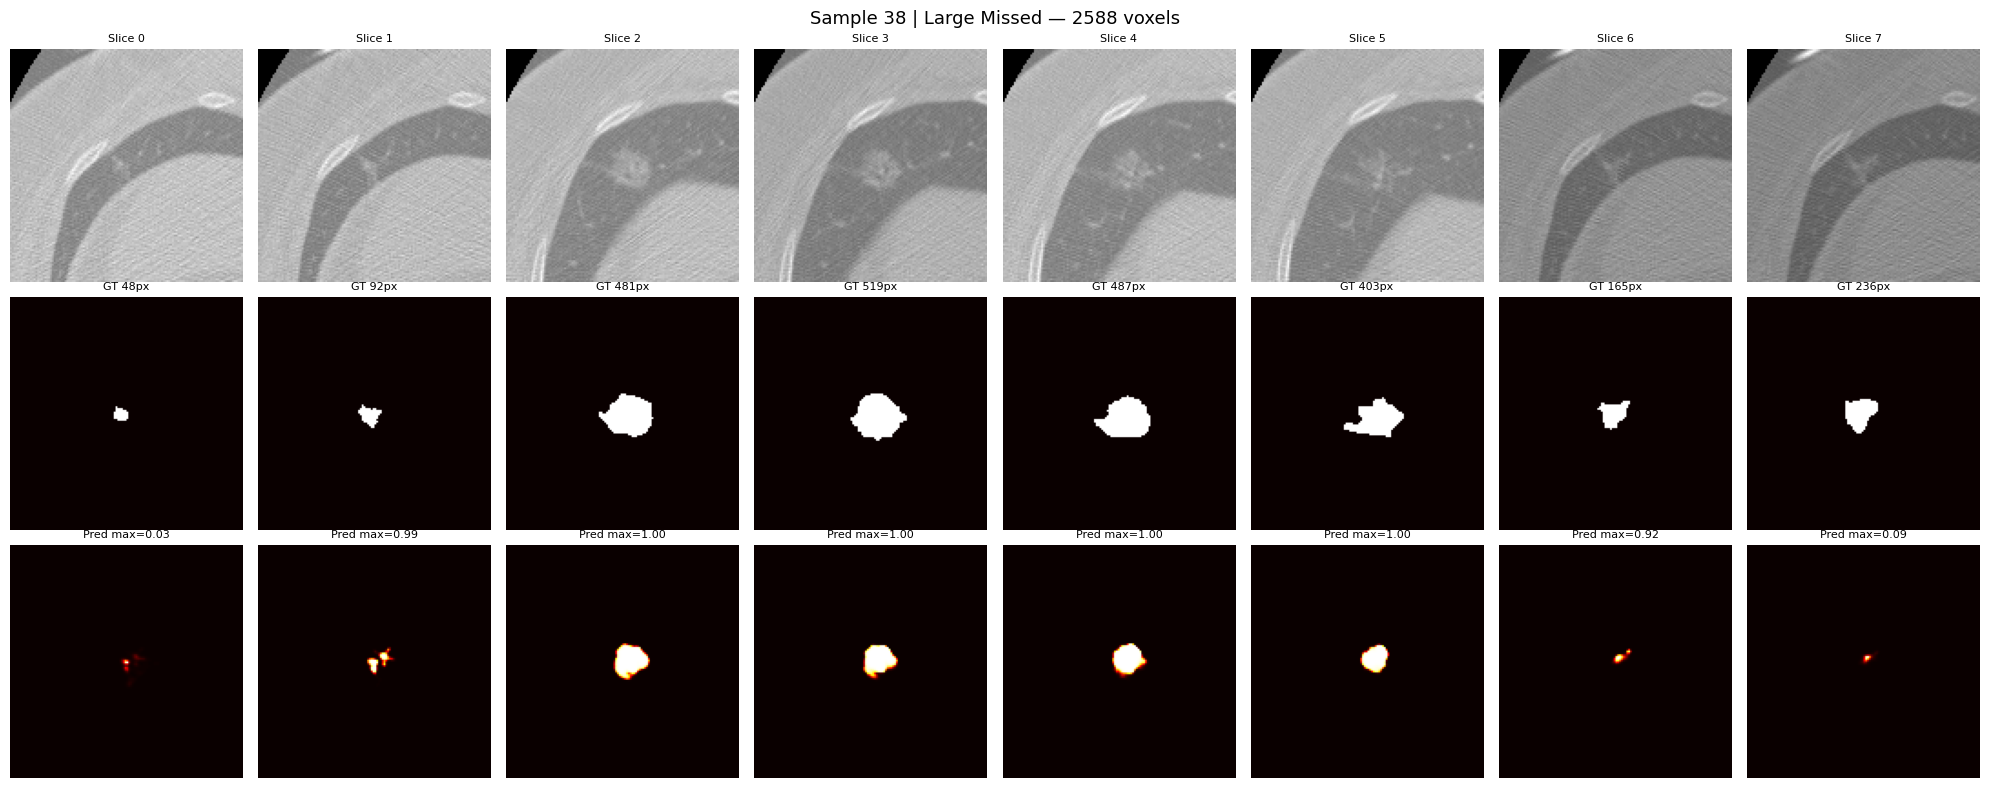

Saved: /content/sample_40.png


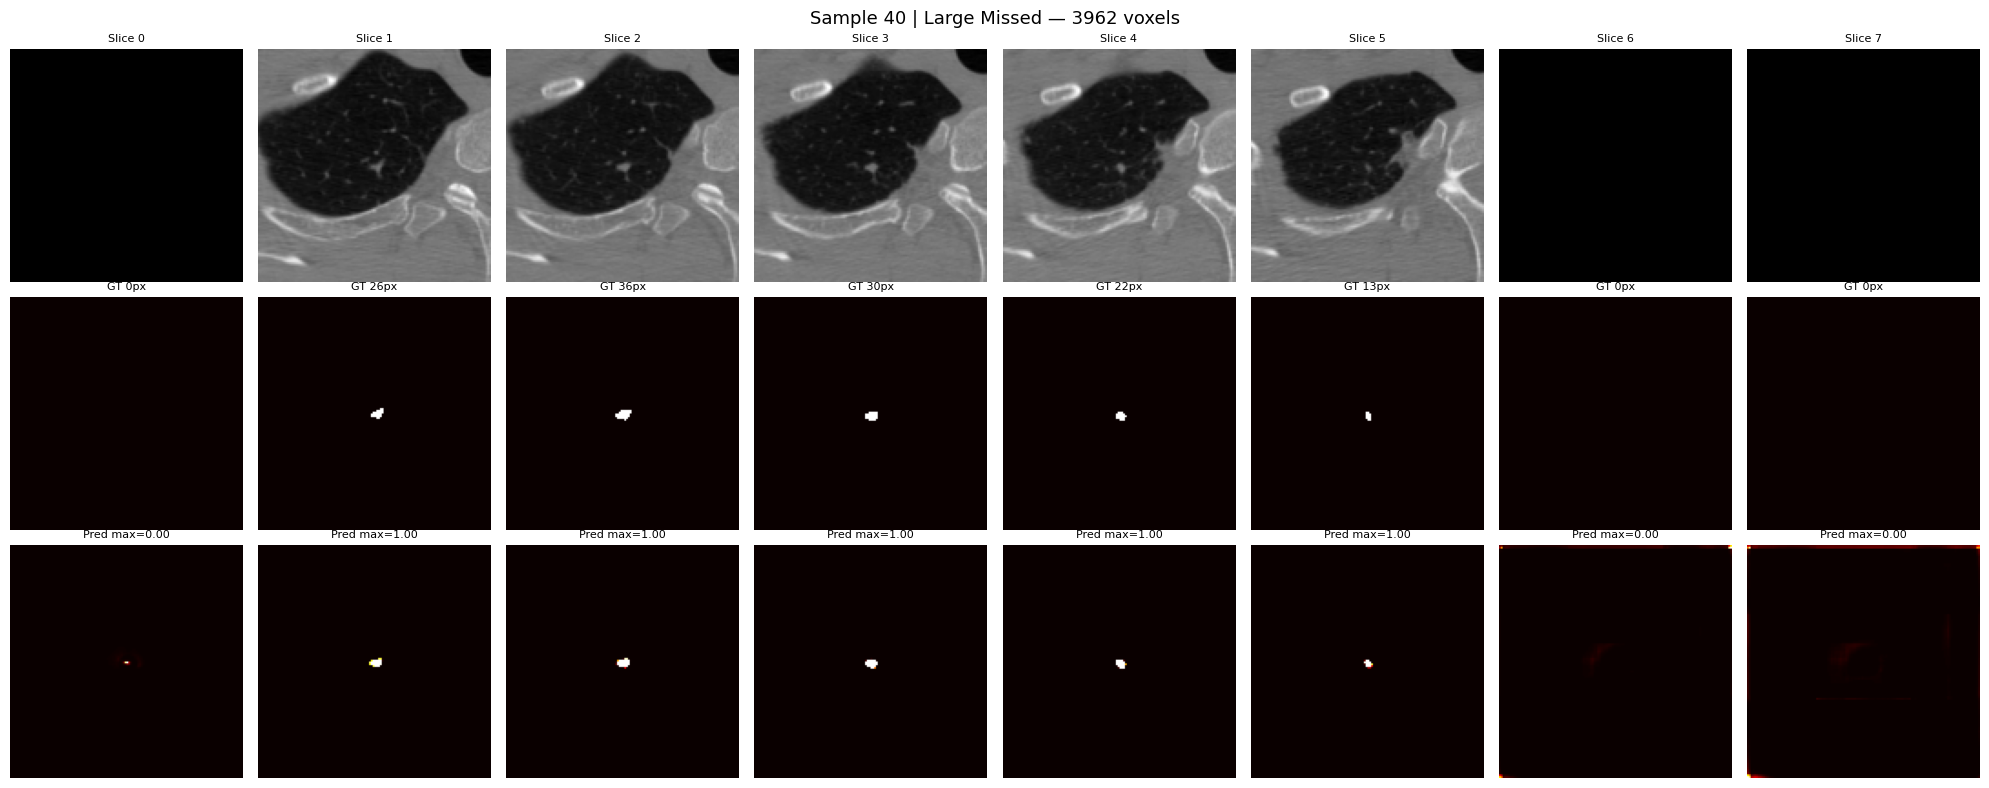

In [ ]:
def plot_miss(X, y_true, y_pred, y_pred_bin, idx, title=""):
    fig, axes = plt.subplots(3, 8, figsize=(20, 8))
    fig.suptitle(f"Sample {idx} | {title}", fontsize=13)

    for s in range(8):
        axes[0, s].imshow(X[idx, s, :, :, 0], cmap='gray')
        axes[0, s].set_title(f'Slice {s}', fontsize=8)
        axes[0, s].axis('off')

        axes[1, s].imshow(y_true[idx, s, :, :, 0], cmap='hot')
        axes[1, s].set_title(f'GT {int(np.sum(y_true[idx,s]))}px', fontsize=8)
        axes[1, s].axis('off')

        axes[2, s].imshow(y_pred[idx, s, :, :, 0], cmap='hot')
        axes[2, s].set_title(f'Pred max={y_pred[idx,s,:,:,0].max():.2f}', fontsize=8)
        axes[2, s].axis('off')

    axes[0, 0].set_ylabel('Input', fontsize=9)
    axes[1, 0].set_ylabel('Ground Truth', fontsize=9)
    axes[2, 0].set_ylabel('Raw Prediction', fontsize=9)
    # Add this at the end of Cell 8, inside the function before plt.show()
    plt.savefig(f'/content/sample_{idx}.png', dpi=100, bbox_inches='tight')
    print(f"Saved: /content/sample_{idx}.png")

    plt.tight_layout()
    plt.show()

# Visualize the two large missed nodules
plot_miss(X_test, y_test, y_pred, y_pred_bin, idx=38,
          title="Large Missed — 2588 voxels")

plot_miss(X_test, y_test, y_pred, y_pred_bin, idx=40,
          title="Large Missed — 3962 voxels")

In [ ]:
thresholds = np.arange(0.25, 0.55, 0.05)

print("Threshold | Mean Dice | Perfect | Complete Miss")
print("-" * 55)

for thresh in thresholds:
    pred_t = (y_pred > thresh).astype(np.float32)
    res = compute_metrics(y_test, pred_t)

    dice_vals = np.array([r['dice'] for r in res])
    mean_dice    = np.mean(dice_vals)
    perfect      = np.sum(dice_vals > 0.85)
    complete_miss = np.sum(dice_vals <= 0.01)

    marker = " ← current" if abs(thresh - 0.5) < 0.01 else ""
    print(f"  {thresh:.2f}    |  {mean_dice:.4f}   |  {perfect:4d}   |  {complete_miss:4d}{marker}")

Threshold | Mean Dice | Perfect | Complete Miss
-------------------------------------------------------
  0.25    |  0.7838   |   143   |     4
  0.30    |  0.7841   |   144   |     4
  0.35    |  0.7841   |   141   |     4
  0.40    |  0.7842   |   141   |     4
  0.45    |  0.7844   |   140   |     4
  0.50    |  0.7842   |   138   |     4 ← current
  0.55    |  0.7839   |   140   |     4


In [ ]:
!pip install gradio huggingface_hub -q
print("Done ✓")

Done ✓


In [ ]:
import shutil

src  = BASE + 'NB3_best.keras'
dest = '/content/lung_tumor_model.keras'

shutil.copy(src, dest)
print("Model copied ✓")
print("File size:", round(os.path.getsize(dest) / 1e6, 1), "MB")

Model copied ✓
File size: 18.0 MB


In [35]:
app_code = '''
import gradio as gr
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.use("Agg")
from PIL import Image
import io

# ── Custom loss functions ──────────────────────────────────────
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    y_pred  = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    bce     = -y_true * tf.math.log(y_pred) - (1.0 - y_true) * tf.math.log(1.0 - y_pred)
    p_t     = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
    focal_w = alpha * tf.pow(1.0 - p_t, gamma)
    return tf.reduce_mean(focal_w * bce)

def focal_dice_loss(y_true, y_pred):
    return 0.5 * focal_loss(y_true, y_pred) + 0.5 * (1.0 - dice_coefficient(y_true, y_pred))

# ── Load model ─────────────────────────────────────────────────
model = tf.keras.models.load_model(
    "lung_tumor_model.keras",
    custom_objects={
        "focal_dice_loss":  focal_dice_loss,
        "dice_coefficient": dice_coefficient,
        "focal_loss":       focal_loss
    }
)
print("Model loaded ✓")

# ── Helper: bounding box ───────────────────────────────────────
def get_bbox(mask):
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    if not rows.any():
        return None
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return rmin, cmin, rmax, cmax

# ── Helper: location label ─────────────────────────────────────
def get_location(bbox, img_size=128):
    if bbox is None:
        return "N/A"
    rmin, cmin, rmax, cmax = bbox
    cx = (cmin + cmax) / 2
    cy = (rmin + rmax) / 2
    v = "Upper" if cy < img_size // 2 else "Lower"
    h = "Left"  if cx < img_size // 2 else "Right"
    return f"{v}-{h} region"

# ── Predict ────────────────────────────────────────────────────
def predict(npy_file):
    try:
        volume = np.load(npy_file.name)

        if volume.ndim == 3:
            volume = volume[..., np.newaxis]
        if volume.shape == (128, 128, 8, 1):
            volume = np.transpose(volume, (2, 0, 1, 3))
        if volume.max() > 1.0:
            volume = volume / 255.0

        if volume.shape != (8, 128, 128, 1):
            return None, f"❌ Wrong shape: {volume.shape}. Expected (8,128,128,1)"

        inp  = volume[np.newaxis, ...].astype(np.float32)
        pred = model.predict(inp, verbose=0)[0]
        pred_bin = (pred > 0.45).astype(np.float32)

        total_voxels   = int(np.sum(pred_bin))
        max_confidence = float(pred.max())
        active_slices  = int(np.sum([pred_bin[s].sum() > 0 for s in range(8)]))
        detected       = total_voxels > 10 and max_confidence > 0.45

        slice_counts = [int(pred_bin[s].sum()) for s in range(8)]
        best_slice   = int(np.argmax(slice_counts))
        bbox         = get_bbox(pred_bin[best_slice, :, :, 0])
        location     = get_location(bbox)

        if total_voxels > 800:
            risk, risk_color = "High",   "#ff4444"
        elif total_voxels > 300:
            risk, risk_color = "Medium", "#ffaa00"
        else:
            risk, risk_color = "Low",    "#44ff44"

        fig, axes = plt.subplots(3, 8, figsize=(22, 9))
        fig.patch.set_facecolor("#0f0f0f")

        status_text  = "⚠ TUMOUR DETECTED"  if detected else "✓ NO TUMOUR DETECTED"
        status_color = "#ff4444"             if detected else "#44ff88"
        fig.suptitle(status_text, color=status_color,
                     fontsize=16, fontweight="bold", y=1.02)

        for s in range(8):
            is_best    = (s == best_slice)
            ct_slice   = volume[s, :, :, 0]
            pred_slice = pred[s, :, :, 0]
            bin_slice  = pred_bin[s, :, :, 0]
            border_col = "#ff4444" if is_best else "#333333"

            axes[0, s].imshow(ct_slice, cmap="gray", vmin=0, vmax=1)
            axes[0, s].set_title(
                f"Slice {s}" + (" ★" if is_best else ""),
                color="#ffdd00" if is_best else "white",
                fontsize=8, fontweight="bold" if is_best else "normal"
            )
            axes[0, s].axis("off")
            axes[0, s].set_facecolor("#0f0f0f")
            for spine in axes[0, s].spines.values():
                spine.set_edgecolor(border_col)
                spine.set_linewidth(2 if is_best else 0.5)

            axes[1, s].imshow(pred_slice, cmap="hot", vmin=0, vmax=1)
            axes[1, s].set_title(f"conf={pred_slice.max():.2f}", color="white", fontsize=7)
            axes[1, s].axis("off")
            axes[1, s].set_facecolor("#0f0f0f")

            axes[2, s].imshow(ct_slice, cmap="gray", vmin=0, vmax=1)
            if bin_slice.max() > 0:
                overlay = np.zeros((*bin_slice.shape, 4))
                overlay[bin_slice == 1] = [1, 0.2, 0.2, 0.55]
                axes[2, s].imshow(overlay)
                if is_best and bbox is not None:
                    rmin, cmin, rmax, cmax = bbox
                    rect = mpatches.Rectangle(
                        (cmin, rmin), cmax - cmin, rmax - rmin,
                        linewidth=2, edgecolor="#ff4444",
                        facecolor="none", linestyle="--"
                    )
                    axes[2, s].add_patch(rect)
                    axes[2, s].text(
                        cmin, rmin - 4, "TUMOR",
                        color="#ff4444", fontsize=7, fontweight="bold"
                    )

            axes[2, s].set_title(f"{int(bin_slice.sum())}px", color="white", fontsize=7)
            axes[2, s].axis("off")
            axes[2, s].set_facecolor("#0f0f0f")

        for row, label in enumerate(["CT Scan", "Heatmap", "Overlay"]):
            axes[row, 0].set_ylabel(label, color="white", fontsize=9, labelpad=6)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        buf = io.BytesIO()
        plt.savefig(buf, format="png", dpi=120,
                    bbox_inches="tight", facecolor="#0f0f0f")
        plt.close(fig)
        buf.seek(0)
        result_img = Image.open(buf).copy()

        if detected:
            report = (
                f"⚠️  TUMOUR DETECTED\\n"
                f"{'─'*35}\\n"
                f"Location      : {location}\\n"
                f"Best slice    : Slice {best_slice} (★ highlighted)\\n"
                f"Active slices : {active_slices} / 8\\n"
                f"Nodule size   : {total_voxels} voxels\\n"
                f"Confidence    : {max_confidence*100:.1f}%\\n"
                f"Risk level    : {risk}\\n"
                f"{'─'*35}\\n"
                f"⚠ Research demo only.\\n"
                f"Consult a radiologist for diagnosis."
            )
        else:
            report = (
                f"✅  NO TUMOUR DETECTED\\n"
                f"{'─'*35}\\n"
                f"Max confidence : {max_confidence*100:.1f}%\\n"
                f"Nodule voxels  : {total_voxels}\\n"
                f"Active slices  : {active_slices} / 8\\n"
                f"{'─'*35}\\n"
                f"⚠ Research demo only.\\n"
                f"Consult a radiologist for diagnosis."
            )

        return result_img, report

    except Exception as e:
        return None, f"❌ Error: {str(e)}"

# ── Gradio UI ──────────────────────────────────────────────────
with gr.Blocks(
    theme=gr.themes.Monochrome(),
    title="Lung Tumour Segmentation",
    css="""
    body, .gradio-container, .main, footer {
        background-color: #0f0f0f !important;
        color: white !important;
    }
    html {
        background-color: #0f0f0f !important;
    }
    .block, .form, .box, .panel {
        background-color: #1a1a1a !important;
        border-color: #333333 !important;
    }
    textarea, input, .input-text {
        background-color: #1a1a1a !important;
        color: white !important;
    }
    button.primary {
        background-color: #cc0000 !important;
    }
    """
) as demo:

    gr.Markdown("""
    # 🫁 Lung Tumour Segmentation — AI Demo
    **Model:** 3D Attention U-Net | **Dataset:** LIDC-IDRI | **Test Dice:** 0.7842 | **Sensitivity:** 0.8136
    Upload a `.npy` CT volume of shape `(8, 128, 128, 1)` → Model segments and detects tumour region.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            inp = gr.File(label="Upload .npy CT Volume", file_types=[".npy"])
            btn = gr.Button("🔍 Run Detection", variant="primary")
            gr.Markdown("""
            **How to prepare input:**
```python
import numpy as np
sample = X_val[0]        # shape (8,128,128,1)
np.save("sample.npy", sample)
```
            Then upload `sample.npy` here.
            """)

        with gr.Column(scale=2):
            out_img = gr.Image(label="Detection Result", type="pil")
            out_txt = gr.Textbox(label="🏥 Detection Report", lines=12)

    btn.click(fn=predict, inputs=inp, outputs=[out_img, out_txt])

    gr.Markdown("""
    ---
    > ★ = Best slice (most tumour voxels) | Red dashed box = Tumour location
    > Row 1: Input CT | Row 2: Confidence heatmap | Row 3: Segmentation overlay
    > **Built by TanishDevX** | LIDC-IDRI | 3D Attention U-Net | Focal+Dice Loss | Threshold: 0.45
    """)

demo.launch()
'''

with open('/content/app.py', 'w') as f:
    f.write(app_code)

print("app.py written ✓")
print("Lines:", len(app_code.splitlines()))

app.py written ✓
Lines: 254


In [36]:
requirements = '''gradio
tensorflow
numpy
matplotlib
Pillow
'''

with open('/content/requirements.txt', 'w') as f:
    f.write(requirements)

print("requirements.txt created ✓")

requirements.txt created ✓


In [37]:
from google.colab import userdata

token = userdata.get('HF_TOKEN')
print(f"Token starts with: {token[:8]}...")
print(f"Token length: {len(token)}")

Token starts with: hf_UnMWU...
Token length: 37


In [38]:
from google.colab import userdata
from huggingface_hub import HfApi, login

# Step 1 - get token
token = userdata.get('HF_TOKEN')

# Step 2 - login
login(token=token)

# Step 3 - pass token explicitly to whoami
api = HfApi()
user = api.whoami(token=token)  # ← pass token directly, don't rely on cached login
print(f"Logged in as: {user['name']} ✓")

Logged in as: TanishDevX ✓


In [39]:
from google.colab import userdata
from huggingface_hub import HfApi

# Get token and create api WITH token baked in
token = userdata.get('HF_TOKEN')
api = HfApi(token=token)  # ← token passed here, no need to pass it again

USERNAME  = "TanishDevX"
REPO_NAME = "lung-tumor-segmentation"
REPO_ID   = f"{USERNAME}/{REPO_NAME}"

# Create Space
api.create_repo(
    repo_id=REPO_ID,
    repo_type="space",
    space_sdk="gradio",
    exist_ok=True
)
print(f"Space created ✓")

# Upload files
files_to_upload = {
    '/content/app.py'                 : 'app.py',
    '/content/requirements.txt'       : 'requirements.txt',
    '/content/lung_tumor_model.keras' : 'lung_tumor_model.keras',
}

for local_path, repo_path in files_to_upload.items():
    print(f"Uploading {repo_path}...")
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo=repo_path,
        repo_id=REPO_ID,
        repo_type="space"
    )
    print(f"  ✓ {repo_path} done")

print(f"\n✅ All uploaded!")
print(f"🚀 https://huggingface.co/spaces/{REPO_ID}")
print("⏳ Wait 2-3 mins for build, then open the link")

Space created ✓
Uploading app.py...


No files have been modified since last commit. Skipping to prevent empty commit.


  ✓ app.py done
Uploading requirements.txt...
  ✓ requirements.txt done
Uploading lung_tumor_model.keras...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nt/lung_tumor_model.keras: 100%|##########| 18.0MB / 18.0MB            

No files have been modified since last commit. Skipping to prevent empty commit.


  ✓ lung_tumor_model.keras done

✅ All uploaded!
🚀 https://huggingface.co/spaces/TanishDevX/lung-tumor-segmentation
⏳ Wait 2-3 mins for build, then open the link


In [29]:
import numpy as np

dice_scores = np.array([r['dice'] for r in results])

# Top 10 best predicted samples from TEST set
top_indices = np.argsort(dice_scores)[::-1][:10]

print("Top 10 demo samples (from test set):")
for idx in top_indices:
    print(f"  Sample {idx} → Dice: {dice_scores[idx]:.4f}")
    np.save(f'/content/demo_sample_{idx}.npy', X_test[idx])

print("\nDownload these for your demo!")

Top 10 demo samples (from test set):
  Sample 273 → Dice: 0.9524
  Sample 76 → Dice: 0.9524
  Sample 174 → Dice: 0.9506
  Sample 391 → Dice: 0.9400
  Sample 45 → Dice: 0.9355
  Sample 149 → Dice: 0.9346
  Sample 116 → Dice: 0.9333
  Sample 105 → Dice: 0.9329
  Sample 260 → Dice: 0.9302
  Sample 336 → Dice: 0.9301

Download these for your demo!
